## Setup

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

## Helper Functions

In [3]:
def compute_spectrograms(signal_tensor, n_fft=64, hop_length=4):
    """
    Converts a 3D time-series tensor into a 4D log-spectrogram tensor.
    Safely handles PyTorch STFT dimension requirements.

    Args:
        signal_tensor (Tensor): Input tensor of shape (Samples, Time, Channels).
        n_fft (int): Number of FFT points for STFT.
        hop_length (int): Hop length for STFT.
    
    Returns:
        Tensor: Log-spectrograms of shape (Samples, Channels, FreqBins, TimeFrames).
    """
    # Permute to (Samples, Channels, Time)
    signal_perm = signal_tensor.permute(0, 2, 1)
    
    # Extract dimensions for reshaping
    samples, channels, time_steps = signal_perm.shape
    
    # Flatten Samples and Channels into a single 2D batch dimension
    # Shape becomes: (Samples * Channels, Time) for PyTorch STFT
    signal_2d = signal_perm.reshape(samples * channels, time_steps)
    
    window = torch.hann_window(n_fft).to(signal_tensor.device)
    
    # Compute the STFT
    stft_complex = torch.stft(
        signal_2d, 
        n_fft=n_fft, 
        hop_length=hop_length, 
        window=window, 
        return_complex=True
    )
    
    # Get magnitude and convert to Log Scale (Decibels)
    mag_spectrogram = torch.abs(stft_complex)
    log_spectrogram = 20 * torch.log10(mag_spectrogram + 1e-8)
    
    # Unflatten back to 4D: (Samples, Channels, FreqBins, TimeFrames)
    _, freq_bins, time_frames = log_spectrogram.shape
    final_spectrogram = log_spectrogram.reshape(samples, channels, freq_bins, time_frames)
    
    return final_spectrogram

In [4]:
def normalize_spectrograms(train_spec, test_spec):
    """
    Applies global Z-score normalization based on training data statistics.

    Args:
        train_spec (Tensor): Spectrograms from the training set, shape (Samples, Channels, FreqBins, TimeFrames).
        test_spec (Tensor): Spectrograms from the test set, same shape as train_spec

    Returns:
        train_spec_norm (Tensor): Normalized training spectrograms. Same shape as input.
        test_spec_norm (Tensor): Normalized test spectrograms. Same shape as input.
    """
    # Calculate mean and std ONLY from the training set
    mean = train_spec.mean(dim=(0, 2, 3), keepdim=True)
    std = train_spec.std(dim=(0, 2, 3), keepdim=True)
    
    # Add a tiny epsilon to prevent division by zero
    eps = 1e-8
    
    # Normalize both datasets using the TRAIN statistics
    train_spec_norm = (train_spec - mean) / (std + eps)
    test_spec_norm = (test_spec - mean) / (std + eps)
    
    return train_spec_norm, test_spec_norm

In [5]:
def plot_precomputed_spectrogram(spec_tensor, title="Spectrogram", sample_rate=50, hop_length=4):
    """
    Plots a precomputed 3-channel spectrogram tensor.
    
    Args:
        spec_tensor: 3D tensor of shape (3, FreqBins, TimeFrames)
        title: Title of the overall figure
        sample_rate: The original sampling rate in Hz
        hop_length: The hop length used during the STFT
    """
    # Convert to NumPy for Matplotlib
    if isinstance(spec_tensor, torch.Tensor):
        spec_tensor = spec_tensor.numpy()
        
    channels, freq_bins, time_frames = spec_tensor.shape
    
    # Calculate the physical bounds for the axes
    max_time = (time_frames * hop_length) / sample_rate
    nyquist_freq = sample_rate / 2
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    fig.suptitle(title, fontsize=14)
    
    axis_names = ['X-axis', 'Y-axis', 'Z-axis']
    
    for i in range(channels):
        im = axes[i].imshow(
            spec_tensor[i], 
            origin='lower', 
            aspect='auto', 
            cmap='magma', 
            extent=[0, max_time, 0, nyquist_freq]
        )
        
        axes[i].set_title(axis_names[i])
        axes[i].set_xlabel("Time (seconds)")
        if i == 0:
            axes[i].set_ylabel("Frequency (Hz)")
            
    # Add a unified colorbar
    fig.colorbar(im, ax=axes.ravel().tolist(), label="Magnitude (dB)", aspect=40)
    plt.show()

In [6]:
def plot_time_series(time_signal, title="Time Series", sample_rate=50):
    """
    Plots a 3-channel time-domain signal.
    
    Args:
        time_signal (torch.Tensor or np.ndarray): Time-domain signal with shape (Samples, Channels).
        title (str): Title for the plot.
        sample_rate (int): Sampling rate of the original signal in Hz (default is 50).
    
    Returns:
        None: Displays the plot of the time series.
    """
    # Convert to numpy if it's a PyTorch tensor
    if isinstance(time_signal, torch.Tensor):
        time_signal = time_signal.numpy()
        
    n_samples = time_signal.shape[0]
    time_axis = np.linspace(0, n_samples / sample_rate, n_samples)
    
    plt.figure(figsize=(12, 6))
    plt.plot(time_axis, time_signal)
    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.legend(['X-axis', 'Y-axis', 'Z-axis'], loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

## Helper Classes

In [7]:
class HARDataLoader:
    """
    A management class for loading the UCI Human Activity Recognition Dataset.
    """
    
    def __init__(self, root_dir='data/raw'):
        """
        Initializes the loader with the root data directory.
        Uses pathlib for robust, cross-platform path handling. 
        
        Args:
            root_dir (str): Relative path to the raw data folder.
        """
        self.root = Path(root_dir)
        
    def _load_files_in_folder(self, folder_path, prefix, dataset_type):
        """
        Internal helper to combine X, Y, and Z axis text files into a 3D tensor.
        
        Args:
            folder_path (Path): Path to the 'Inertial Signals' directory.
            prefix (str): Signal type (e.g., 'total_acc' or 'body_gyro').
            dataset_type (str): 'train' or 'test'.
            
        Returns:
            torch.Tensor: A 3D tensor with shape (samples, 128, 3). [cite: 6]
        """
        axes = ['x', 'y', 'z']
        data = []
        
        for axis in axes:
            # Construct filename based on axis and split (e.g., total_acc_x_train.txt)
            file_name = f'{prefix}_{axis}_{dataset_type}.txt'
            file_path = folder_path / file_name
            
            if not file_path.exists():
                raise FileNotFoundError(f"Missing expected data file: {file_path}")
            
            # Load space-separated data into NumPy
            data_array = pd.read_csv(file_path, sep=r'\s+', header=None).values
            data.append(data_array)
            
        # Stack along the last dimension to create shape: (Samples, TimeSteps, Channels)
        # Convert to float32 for compatibility with PyTorch CNN layers
        return torch.tensor(np.stack(data, axis=-1), dtype=torch.float32)

    def get_split(self, split='train'):
        """
        Retrieves the accelerometer, gyroscope, and label tensors for a split.
        
        Args:
            split (str): The dataset partition to load ('train' or 'test').
            
        Returns:
            total_accel (Tensor): Total acceleration (including gravity).
            body_accel (Tensor): Body acceleration.
            body_gyro (Tensor): Body angular velocity.
            labels (Tensor): 0-indexed activity labels (Long).
        """
        split_dir = self.root / split
        signal_dir = split_dir / 'Inertial Signals'
        
        # Load total accelerometer data (total acceleration = body + gravity)
        total_accel = self._load_files_in_folder(signal_dir, 'total_acc', split)
        
        # Load total accelerometer data (total acceleration = body + gravity)
        body_accel = self._load_files_in_folder(signal_dir, 'body_acc', split)

        # Load gyroscope data
        body_gyro = self._load_files_in_folder(signal_dir, 'body_gyro', split)
        
        # Load labels from y_train.txt or y_test.txt
        label_file = split_dir / f'y_{split}.txt'
        y_raw = pd.read_csv(label_file, sep=r'\s+', header=None).values
        
        # Flatten to 1D and shift labels 1-6 down to 0-5 for CrossEntropyLoss
        labels = torch.tensor(y_raw.squeeze(), dtype=torch.long) - 1
        
        return total_accel, body_accel, body_gyro, labels

## Loading Raw Data

In [8]:
loader = HARDataLoader('../data/raw') # Initializes data loader to correct path

In [9]:
# Load training data and print shapes to verify
train_total_accel, train_body_accel, train_body_gyro, train_labels = loader.get_split('train')

print(f"Train total accel shape: {train_total_accel.shape}")
print(f"Train body accel shape: {train_body_accel.shape}")
print(f"Train body gyro shape: {train_body_gyro.shape}")
print(f"Train labels shape: {train_labels.shape}")

Train total accel shape: torch.Size([7352, 128, 3])
Train body accel shape: torch.Size([7352, 128, 3])
Train body gyro shape: torch.Size([7352, 128, 3])
Train labels shape: torch.Size([7352])


In [10]:
# Load test data and print shapes to verify
test_total_accel, test_body_accel, test_body_gyro, test_labels = loader.get_split('test')

print(f"Test total accel shape: {test_total_accel.shape}")
print(f"Test body accel shape: {test_body_accel.shape}")
print(f"Test body gyro shape: {test_body_gyro.shape}")
print(f"Test labels shape: {test_labels.shape}")

Test total accel shape: torch.Size([2947, 128, 3])
Test body accel shape: torch.Size([2947, 128, 3])
Test body gyro shape: torch.Size([2947, 128, 3])
Test labels shape: torch.Size([2947])


In [11]:
train_body_accel_spec = compute_spectrograms(train_body_accel)
test_body_accel_spec = compute_spectrograms(test_body_accel)

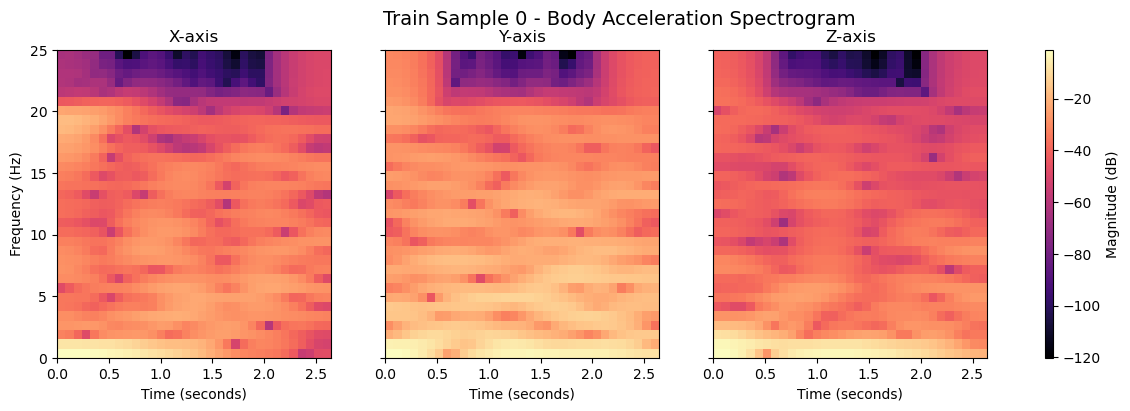

In [12]:
plot_precomputed_spectrogram(train_body_accel_spec[0], title=f"Train Sample {0} - Body Acceleration Spectrogram")

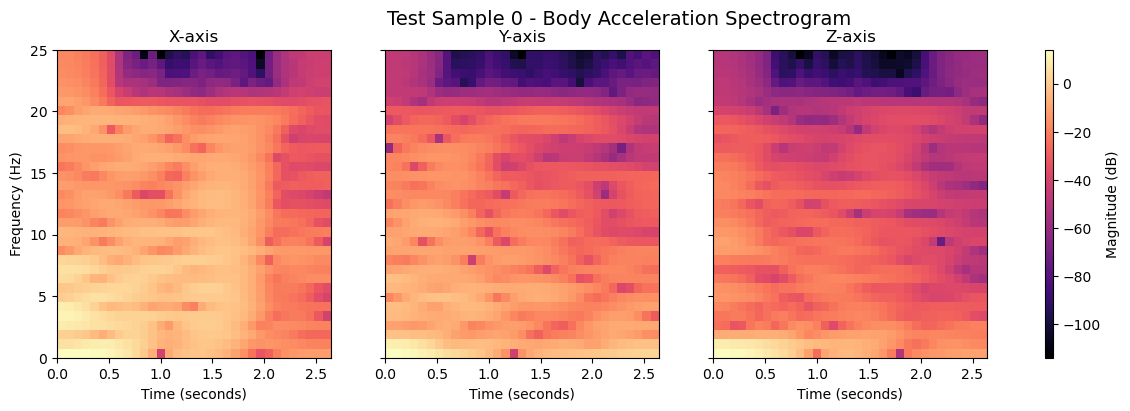

In [13]:
plot_precomputed_spectrogram(test_body_accel_spec[0], title=f"Test Sample {0} - Body Acceleration Spectrogram")

In [14]:
print(train_body_accel_spec.shape)
print(test_body_accel_spec.shape)

torch.Size([7352, 3, 33, 33])
torch.Size([2947, 3, 33, 33])


In [15]:
!conda install scikit-learn -y

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda




In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

## Model Definition

In [54]:
class ActivitySpectrogramCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Input shape: [batch, 3, 33, 33]
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.25)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout(0.3)

        # 33x33 -> pool -> 16x16 -> pool -> 8x8 -> pool -> 4x4
        self.fc1 = nn.Linear(64 * 4 * 4, 64)
        self.drop_fc = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 6)   # 6 activity classes

    def forward(self, x):
        # x shape: [batch, 3, 33, 33]

        x = self.pool1(F.relu(self.conv1(x)))
        x = self.drop1(x)

        x = self.pool2(F.relu(self.conv2(x)))
        x = self.drop2(x)

        x = self.pool3(F.relu(self.conv3(x)))
        x = self.drop3(x)

        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc2(x)   # raw class scores (logits)

        return x

In [55]:
train_dataset = TensorDataset(train_body_accel_spec, train_labels)
test_dataset = TensorDataset(test_body_accel_spec, test_labels)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ActivitySpectrogramCNN().to(device)
print(model)

Using device: cpu
ActivitySpectrogramCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.2, inplace=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop3): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=1024, out_features=64, bias=True)
  (drop_fc): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=6, bias=True)
)


In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ActivitySpectrogramCNN().to(device)
print(model)

Using device: cpu
ActivitySpectrogramCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.2, inplace=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop3): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=1024, out_features=64, bias=True)
  (drop_fc): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=6, bias=True)
)


In [58]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [59]:
inputs, labels = next(iter(train_loader))
inputs = inputs.to(device)

outputs = model(inputs)

print("Input batch shape:", inputs.shape)
print("Output batch shape:", outputs.shape)

Input batch shape: torch.Size([64, 3, 33, 33])
Output batch shape: torch.Size([64, 6])


In [60]:
num_epochs = 25

train_loss_history = []
test_loss_history = []
train_acc_history = []
test_acc_history = []

for epoch in range(num_epochs):
    # -------------------
    # TRAINING
    # -------------------
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()              # clear old gradients
        outputs = model(inputs)            # forward pass
        loss = criterion(outputs, labels)  # compute loss
        loss.backward()                    # backpropagation
        optimizer.step()                   # update weights

        running_train_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train

    train_loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc)

    # -------------------
    # TESTING / VALIDATION
    # -------------------
    model.eval()
    running_test_loss = 0.0
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = correct_test / total_test

    test_loss_history.append(epoch_test_loss)
    test_acc_history.append(epoch_test_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Test Loss: {epoch_test_loss:.4f} | "
        f"Test Acc: {epoch_test_acc:.4f}"
    )

Epoch 1/25 | Train Loss: 1.3946 | Train Acc: 0.3323 | Test Loss: 1.0664 | Test Acc: 0.4018
Epoch 2/25 | Train Loss: 0.9820 | Train Acc: 0.5131 | Test Loss: 0.7627 | Test Acc: 0.6590
Epoch 3/25 | Train Loss: 0.7208 | Train Acc: 0.6717 | Test Loss: 0.6265 | Test Acc: 0.7180
Epoch 4/25 | Train Loss: 0.6310 | Train Acc: 0.7101 | Test Loss: 0.5623 | Test Acc: 0.7492
Epoch 5/25 | Train Loss: 0.5951 | Train Acc: 0.7348 | Test Loss: 0.5501 | Test Acc: 0.7340
Epoch 6/25 | Train Loss: 0.5688 | Train Acc: 0.7348 | Test Loss: 0.5395 | Test Acc: 0.7438
Epoch 7/25 | Train Loss: 0.5412 | Train Acc: 0.7548 | Test Loss: 0.5232 | Test Acc: 0.7374
Epoch 8/25 | Train Loss: 0.5324 | Train Acc: 0.7548 | Test Loss: 0.4889 | Test Acc: 0.7618
Epoch 9/25 | Train Loss: 0.5134 | Train Acc: 0.7644 | Test Loss: 0.4699 | Test Acc: 0.7791
Epoch 10/25 | Train Loss: 0.5097 | Train Acc: 0.7688 | Test Loss: 0.4805 | Test Acc: 0.7699
Epoch 11/25 | Train Loss: 0.4852 | Train Acc: 0.7752 | Test Loss: 0.4629 | Test Acc: 0.79

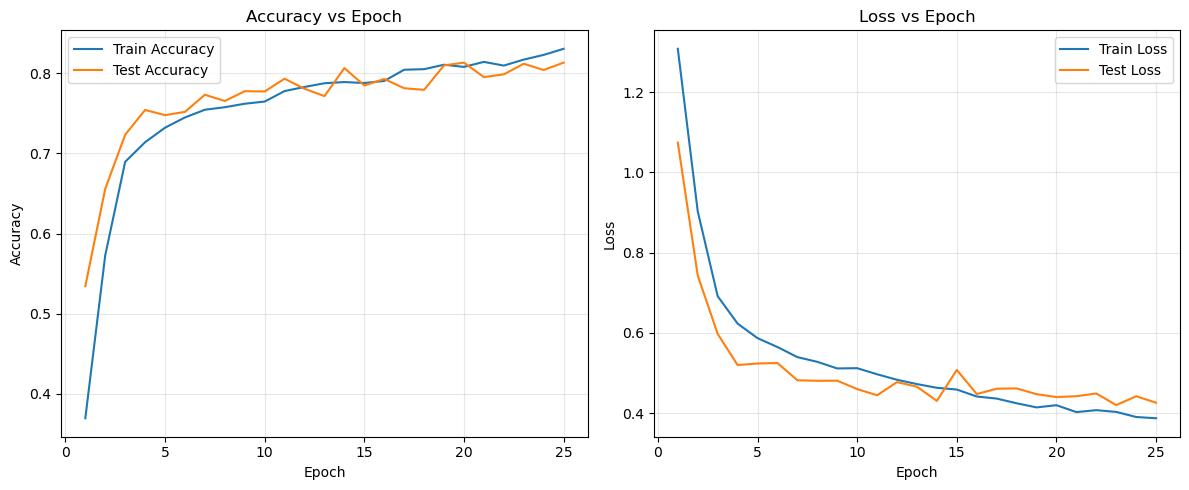

In [41]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc_history, label='Train Accuracy')
plt.plot(epochs, test_acc_history, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss_history, label='Train Loss')
plt.plot(epochs, test_loss_history, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

activity_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=activity_names))

Confusion Matrix:
[[495   0   1   0   0   0]
 [ 18 440  13   0   0   0]
 [ 28  44 348   0   0   0]
 [  0   0   0 244 223  24]
 [  0   0   0  84 426  22]
 [  0   0   0 104  11 422]]

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.91      1.00      0.95       496
  WALKING_UPSTAIRS       0.91      0.93      0.92       471
WALKING_DOWNSTAIRS       0.96      0.83      0.89       420
           SITTING       0.56      0.50      0.53       491
          STANDING       0.65      0.80      0.71       532
            LAYING       0.90      0.79      0.84       537

          accuracy                           0.81      2947
         macro avg       0.82      0.81      0.81      2947
      weighted avg       0.81      0.81      0.80      2947

